# Занятие 4.
__1. Алгоритмы кластеризации__

__2. Линейные модели: линейная и логистическая регрессия__

__3. Кривые валидации и обучения__

In [75]:
# Firstly import all required packages
# enable interactive mode of matplotlib
%matplotlib notebook

# import cv2  # python OpenCV
import os  # 
import numpy as np  # lib for arrays
import datetime
import glob
import pandas as pd

import math as mh  # math package

import matplotlib as mpl  
import matplotlib.pyplot as plt  # namespace for plotting
mpl.rcParams['figure.figsize'] = (6, 5)  # change default value of plot size

# matplotlib based package for pretty visualization
import seaborn as sns
plt.style.use('ggplot')
from sklearn.datasets import load_iris

import time
import pickle  # package for dump & load data
import warnings

tips = sns.load_dataset("tips")

# Алгоритмы кластеризации

Задача кластеризации - разделение входных данных на группы по степени схожести друг друга.

Оценка схожести друг друга выполняется на основе метрики. В качестве метрики наиболее популярны:
* Евклидово расстояние: 
$$ \rho(\mathbf{x}, \mathbf{y}) = \sqrt{\sum_{k=1}^{N}(x_k - y_k)^2}$$

* Квадрат евклидового расстояния
$$ \rho(\mathbf{x}, \mathbf{y}) = \sum_{k=1}^{N}(x_k - y_k)^2$$

* Манхэттенское расстояние
$$ \rho(\mathbf{x}, \mathbf{y}) = \|\mathbf{x} - \mathbf{y}\|_{1} = \sum_{k=1}^{N}\lvert x_k - y_k \rvert $$

* Расстояние Чебышева
$$ \rho(\mathbf{x}, \mathbf{y}) = l_\infty(\mathbf{x}, \mathbf{y}) = \max_{k=1,\ldots,N} \lvert x_k - y_k \rvert $$

* Степенное расстояние (метрика Минковского) порядка $ p $
$$ \rho(\mathbf{x}, \mathbf{y}) = \left(\sum_{k=1}^{N}\lvert x_k - y_k \rvert^p \right)^{\dfrac{1}{p}} $$

Существует ряд алгоритмов кластеризации, каждый из которых обладает особенностями применения. 
Наиболее распространенными алгоритмами кластеризации являются:
* K-means
* Affinity propogation
* DBScan
* MeanShift
* Spectral clustering
* Agglomerative clustering
* Ward
* Birch
* Gaussian Mixture
* Self-Organizing Maps (SOM)
* Growing Neural Gas (GNG)

Сравнения результатов работы некоторых из перечисленных показано в [документации](https://scikit-learn.org/stable/modules/clustering.html#clustering) к библиотеке Scikit-Learn.

## K-means - алгоритм K-средних

Самый распространённый алгоритм кластеризации. 
Выполняется по следующему алгоритму:

1) Выбрать количество кластеров $ k $

2) Случайным образом инициализировать $ k $ точек в пространстве данных

3) Для каждого примера из набора данных посчитать, к какому центроиду она ближе

4) Для каждой выборки перенести центроид в её центр 

5) Повторять последние два шага фиксированное число раз, либо до тех пор пока центроиды не "сойдутся", то есть их смещение относительно предыдущего положения не превышает заданного значения)

<img src="images/kmeans.gif"/>

Пример работы алгоритма на Iris датасете:
<img src="images/kmeans_iris.gif"/>

Crime датасет:
<img src="images/kmeans_crime.gif"/>

Рассмотрим применение алгоритма на синтетических данных шаг за шагом. Создадим случайное распределние трёх кластеров точек на плоскости.

<IPython.core.display.Javascript object>


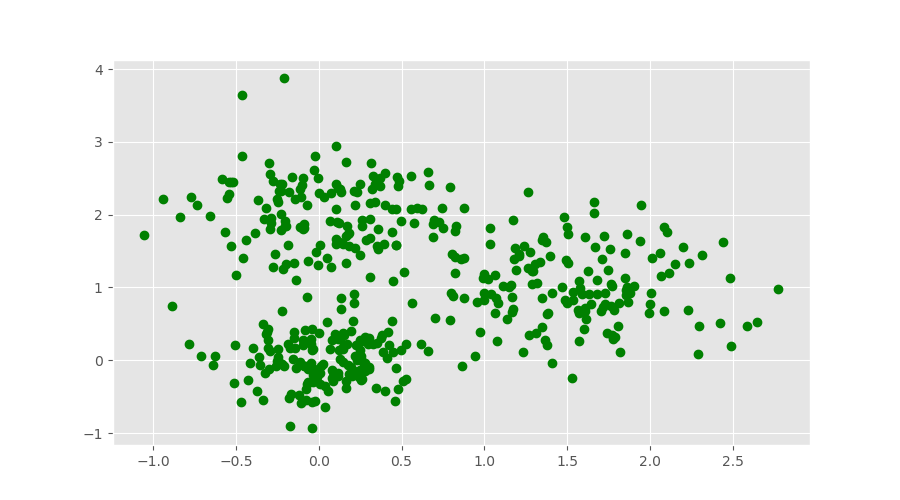

In [76]:
X = np.zeros((450, 2))

np.random.seed(seed=99)
X[:150, 0] = np.random.normal(loc=0.0, scale=.3, size=150)
X[:150, 1] = np.random.normal(loc=0.0, scale=.3, size=150)

X[150:300, 0] = np.random.normal(loc=1.5, scale=.5, size=150)
X[150:300, 1] = np.random.normal(loc=1.0, scale=.5, size=150)

X[300:, 0] = np.random.normal(loc=0.0, scale=.4, size=150)
X[300:, 1] = np.random.normal(loc=2.0, scale=.5, size=150)

plt.figure(figsize=(9, 5))
plt.plot(X[:, 0], X[:, 1], 'go');

Импортируем функцию [cdist](https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.distance.cdist.html) для рассчета расстояний между парами точек двух массивов.

In [16]:
from scipy.spatial.distance import cdist

Установим генератор случайных чисел в фиксированное положение для повторяемости.

In [41]:
np.random.seed(seed=99)

Случайным образом разбросим $k$ точек на плоскости.

In [42]:
centroids = np.random.normal(loc=0.0, scale=0.5, size=6)
centroids = centroids.reshape((3, 2))

Выполним 3 раза пункты 3) и 4) алгоритма и запомним расположение центроидов.

In [43]:
cent_history = []
cent_history.append(centroids)

for i in range(3):
    distances = cdist(X, centroids)
    
    labels = distances.argmin(axis=1)

    centroids = centroids.copy()
    centroids[0, :] = np.mean(X[labels == 0, :], axis=0)
    centroids[1, :] = np.mean(X[labels == 1, :], axis=0)
    centroids[2, :] = np.mean(X[labels == 2, :], axis=0)

    cent_history.append(centroids)

Визуализируем расположение центроидов на каждом шаге.

<IPython.core.display.Javascript object>


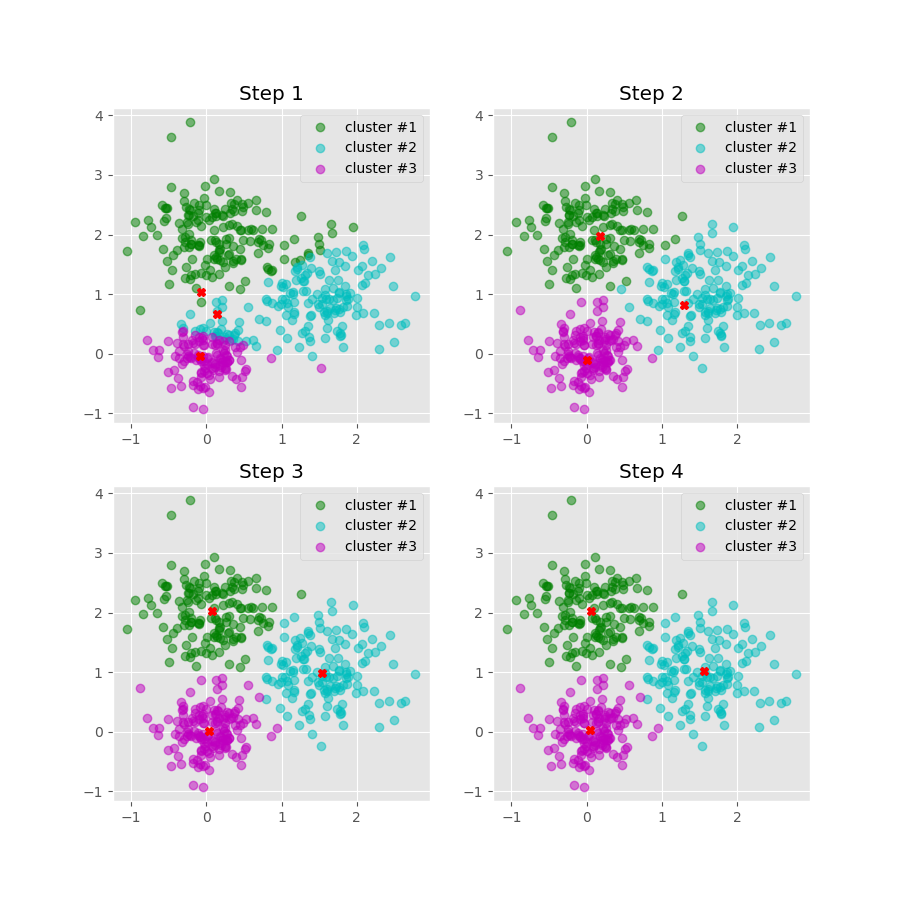

In [77]:
plt.figure(figsize=(9, 9))
for i in range(4):
    distances = cdist(X, cent_history[i])
    labels = distances.argmin(axis=1)

    plt.subplot(2, 2, i + 1)
    plt.plot(X[labels == 0, 0], X[labels == 0, 1], 'go', label='cluster #1', alpha=0.5)
    plt.plot(X[labels == 1, 0], X[labels == 1, 1], 'co', label='cluster #2', alpha=0.5)
    plt.plot(X[labels == 2, 0], X[labels == 2, 1], 'mo', label='cluster #3', alpha=0.5)
    plt.plot(cent_history[i][:, 0], cent_history[i][:, 1], 'rX')
    plt.legend(loc=0)
    plt.title('Step {:}'.format(i + 1));

Конечное расположение кластеров в случае зашумлённых данных сильно зависит от начального положения кластеров. Для компенсации этого эффекта необходимо применять запуск алгоритма несколько раз и получившиеся кластера усреднять.

Для *K-Means* сходимость обеспечивается выбором метрики, количеством кластеров и за количество шагов, к которому сходится алгоритм. Каждый из этих параметров может быть задан заранее. Наиболее важным из этих параметров является количество кластеров $ K $.

Для запуска алгоритма требуется заранее знать количество кластеров $ K $. Но как это сделать на реальных данных, когда это значение неизвестно?

Для этого необходимо представить задачу нахождения центроидов как задачи оптимизации, где функция оптимизации выявит оптимальное значение количества кластеров $ K $. В качестве такой функции выступает сумма квадратов расстояний:

$$ \Large J(C) = \sum_{k=1}^{K}\sum_{i \in C_k} \| x_i - \mu_k \|^2 \rightarrow \min_{C},$$

где $C$ – множество кластеров мощности $K$, $\mu_k$ – центроид кластера $ C_k $.


Необходимо, чтобы точки располагались кучно возле центроидов своих кластеров. Но вот незадача: минимум такого функционала будет достигаться тогда, когда кластеров столько же, сколько и точек (то есть каждая точка – это кластер из одного элемента).

Для решения этого вопроса (выбора числа кластеров) часто пользуются такой эвристикой: выбирают то число кластеров, начиная с которого описанный функционал $J(C)$ падает "уже не так быстро". Или более формально: 

$$ \Large D(k) = \dfrac{\left| J(C_k) - J(C_{k+1}) \right|}{\left| J(C_{k-1}) - J(C_{k}) \right|} \rightarrow \min_{k} $$ 


<IPython.core.display.Javascript object>


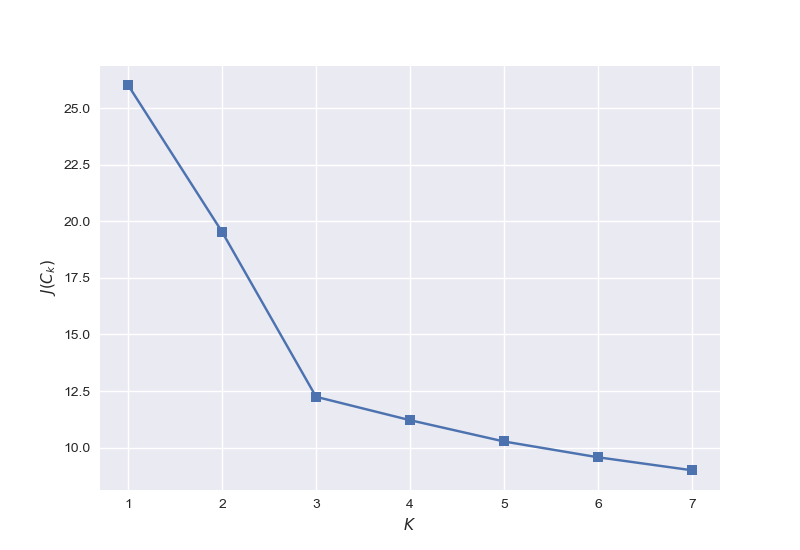

In [47]:
from sklearn.cluster import KMeans

inertia = []
for k in range(1, 8):
    kmeans = KMeans(n_clusters=k, random_state=1).fit(X)
    inertia.append(np.sqrt(kmeans.inertia_))
    
plt.figure()
plt.plot(range(1, 8), inertia, marker='s');
plt.xlabel('$K$')
plt.ylabel('$J(C_k)$');

Из рисунка видно, как при $k=3$ функционал $J(C_k)$ падает медленее. Таким образом, графически понятно, что оптимальное значение кластеров равно 3.

Пример отработки на искусственных данных шаг за шагом:
<img src="images/kmeans_sklearn.gif"/>

**Сложность алгоритма.** Задача K-means является NP-трудной. Для размерности $d$ признакового пространства, числа кластеров $k$ и числа точек $n$ решается за $O(n^{dk+1})$.

Для решения такой боли часто используются эвристики, например [*MiniBatch K-means*](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.MiniBatchKMeans.html), который для обучения использует не весь датасет целиком, а лишь маленькие его порции (batch) и обновляет центроиды используя среднее за всю историю обновлений центроида от всех относящихся к нему точек.

Реализация алгоритма в scikit-learn обладает массой удобных плюшек, таких как возможность задать количество запусков через параметр *n_init*, что даст более устойчивые центроиды для кластеров в случае скошенных данных. К тому же эти запуски можно делать параллельно, не жертвуя временем вычисления.

Существуют различные вариации K-Means, в которых используются различные подходы для улучшения работы алгоритма. Например, умная инициализация центроидов (K-Means++), использование других метрик для обновления расположения центроида (вместо среднего положения используются медиана и [медоид](https://en.wikipedia.org/wiki/K-medoids) (k-medians и k-medoids).

**Пример.** В фильмах иногда используются цветовые палитры для создания необходимой палитры для зрителя. Мы можем рассмотреть пример применения алгоритма K-means для извлечения цветовой гаммы из различных изображений.

Для начала импортируем OpenCV:

In [50]:
import cv2

И загрузим 3 изображения из фильмов:

In [52]:
images = [cv2.imread('./images/cinema_{}.jpg'.format(i))[:,:,::-1] for i in ['martianin', '8', 'survival']]

Посмотрим на изображения:

In [55]:
plt.style.use('default')

<IPython.core.display.Javascript object>


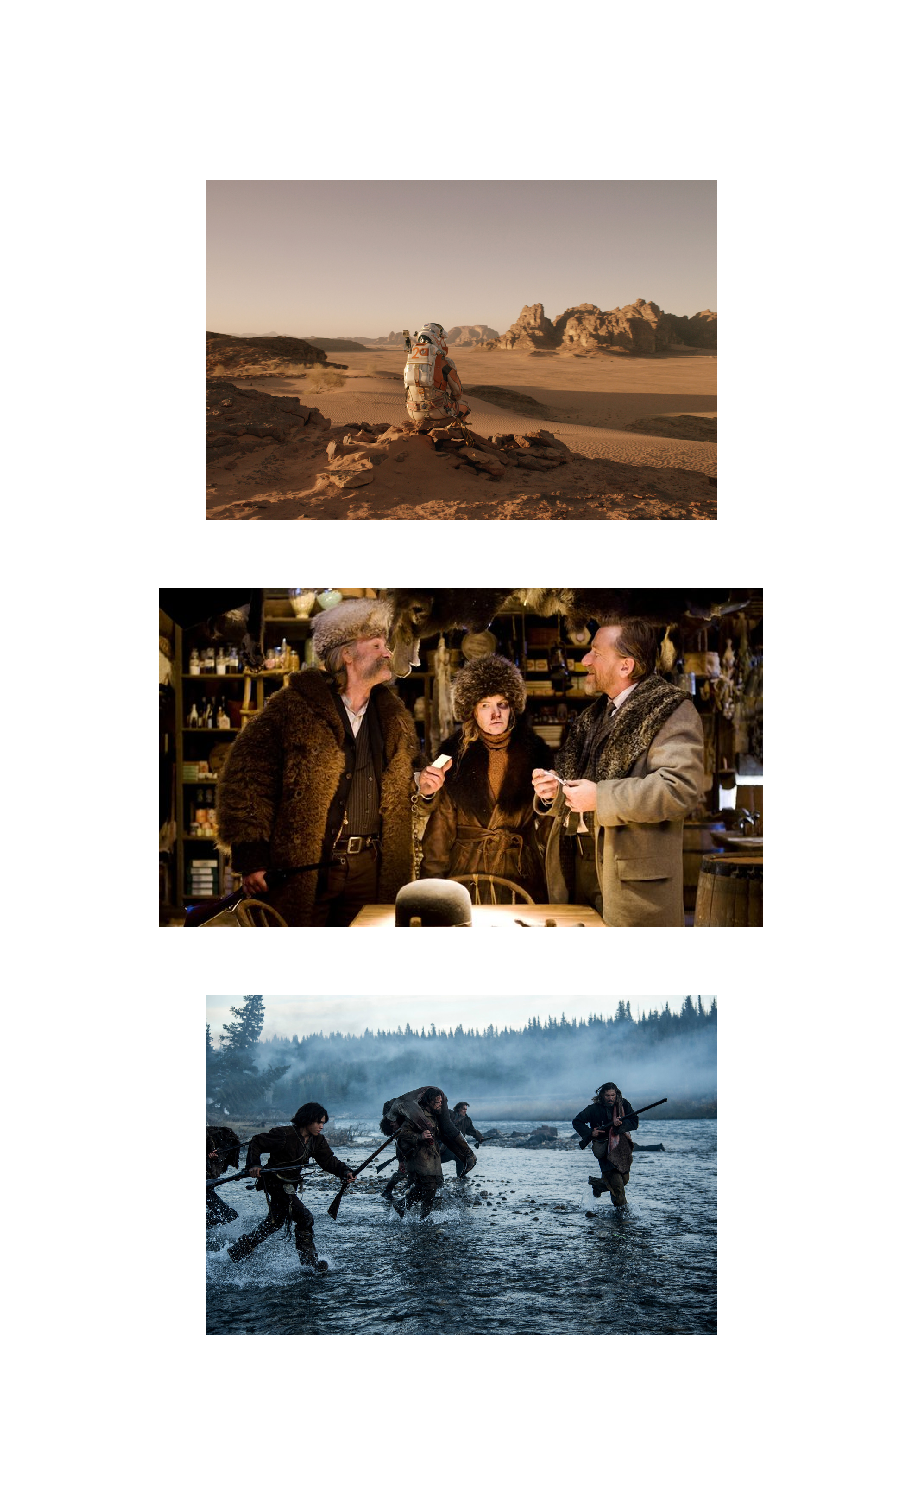

In [78]:
fig, ax = plt.subplots(3, 1, figsize=(9, 15))
ax = ax.ravel()
for i in range(3):
    ax[i].imshow(images[i])
    ax[i].axis('off')

Преобразуем пиксели изображения в массив роазмером $(rows * columns)\,x\,3$:

In [60]:
pixels = [i.reshape(-1, 3) for i in images]

Определим количество цветов, которые мы хотим получить:

In [61]:
n_clusters = 7

Создадим также вспомогательные функции:
* *centroid_histogram* считает количество пикселей внутри каждого кластера
* *plot_colors* визуализирует палитру

In [62]:
def centroid_histogram(clt):
    # grab the number of different clusters and create a histogram
    # based on the number of pixels assigned to each cluster
    numLabels = np.arange(0, len(np.unique(clt.labels_)) + 1)
    (hist, _) = np.histogram(clt.labels_, bins = numLabels)
 
    # normalize the histogram, such that it sums to one
    hist = hist.astype("float")
    hist /= hist.sum()
 
    # return the histogram
    return hist

def plot_colors(hist, centroids):
    # initialize the bar chart representing the relative frequency
    # of each of the colors
    bar = np.zeros((50, 300, 3), dtype = "uint8")
    startX = 0
 
    # loop over the percentage of each cluster and the color of
    # each cluster
    for (percent, color) in zip(hist, centroids):
        # plot the relative percentage of each cluster
        endX = startX + (percent * 300)
        cv2.rectangle(bar, (int(startX), 0), (int(endX), 50),
                      color.astype("uint8").tolist(), -1)
        startX = endX

    # return the bar chart
    return bar

Для каждой из картинки найдём её цветовую палитру, обучив последовательно алгоритм K-Means на наборе пикселей. Параметр *Verbose* позволяет в виде текста получать информацию о процессе обучения.

In [66]:
palletes = []
for i in range(3):
    
    print('Training for {} image'.format(i))
    
    clt = KMeans(n_clusters=n_clusters, verbose=True)
    clt.fit(pixels[i])
    
    hist = centroid_histogram(clt)
    bar = plot_colors(hist, clt.cluster_centers_)
    
    palletes.append(bar)

Training for 0 image
Initialization complete
start iteration
done sorting
end inner loop
Iteration 0, inertia 192183321.3413729
start iteration
done sorting
end inner loop
Iteration 1, inertia 182891496.63759902
start iteration
done sorting
end inner loop
Iteration 2, inertia 179167839.92665213
start iteration
done sorting
end inner loop
Iteration 3, inertia 177035663.85945758
start iteration
done sorting
end inner loop
Iteration 4, inertia 175861196.5697139
start iteration
done sorting
end inner loop
Iteration 5, inertia 175219098.8180631
start iteration
done sorting
end inner loop
Iteration 6, inertia 174867802.26677337
start iteration
done sorting
end inner loop
Iteration 7, inertia 174673465.1136211
start iteration
done sorting
end inner loop
Iteration 8, inertia 174566129.35869196
start iteration
done sorting
end inner loop
Iteration 9, inertia 174491929.98970598
start iteration
done sorting
end inner loop
Iteration 10, inertia 174441529.67251834
start iteration
done sorting
end i

Initialization complete
start iteration
done sorting
end inner loop
Iteration 0, inertia 206361912.96999303
start iteration
done sorting
end inner loop
Iteration 1, inertia 196501370.4455525
start iteration
done sorting
end inner loop
Iteration 2, inertia 190190502.24393487
start iteration
done sorting
end inner loop
Iteration 3, inertia 186141584.7076974
start iteration
done sorting
end inner loop
Iteration 4, inertia 183291646.68517923
start iteration
done sorting
end inner loop
Iteration 5, inertia 181661522.0109124
start iteration
done sorting
end inner loop
Iteration 6, inertia 180620331.29107904
start iteration
done sorting
end inner loop
Iteration 7, inertia 179863032.95068523
start iteration
done sorting
end inner loop
Iteration 8, inertia 179207652.96778578
start iteration
done sorting
end inner loop
Iteration 9, inertia 178759461.5353155
start iteration
done sorting
end inner loop
Iteration 10, inertia 178278711.04267603
start iteration
done sorting
end inner loop
Iteration 1

Initialization complete
start iteration
done sorting
end inner loop
Iteration 0, inertia 178463038.89971218
start iteration
done sorting
end inner loop
Iteration 1, inertia 173555766.05469716
start iteration
done sorting
end inner loop
Iteration 2, inertia 171546037.0198267
start iteration
done sorting
end inner loop
Iteration 3, inertia 170991739.55964795
start iteration
done sorting
end inner loop
Iteration 4, inertia 170738945.82932827
start iteration
done sorting
end inner loop
Iteration 5, inertia 170594972.1657961
start iteration
done sorting
end inner loop
Iteration 6, inertia 170557034.84360594
start iteration
done sorting
end inner loop
Iteration 7, inertia 170546985.06368116
center shift 4.577565e-01 within tolerance 3.140160e-01
Initialization complete
start iteration
done sorting
end inner loop
Iteration 0, inertia 225284164.23886693
start iteration
done sorting
end inner loop
Iteration 1, inertia 202700708.52396345
start iteration
done sorting
end inner loop
Iteration 2, i

Iteration 10, inertia 119542921.95338151
start iteration
done sorting
end inner loop
Iteration 11, inertia 119400792.99270843
start iteration
done sorting
end inner loop
Iteration 12, inertia 119287083.41917224
start iteration
done sorting
end inner loop
Iteration 13, inertia 119197584.31655948
start iteration
done sorting
end inner loop
Iteration 14, inertia 119113948.8387613
start iteration
done sorting
end inner loop
Iteration 15, inertia 119042105.19562069
start iteration
done sorting
end inner loop
Iteration 16, inertia 118979114.99501653
start iteration
done sorting
end inner loop
Iteration 17, inertia 118928453.41470234
start iteration
done sorting
end inner loop
Iteration 18, inertia 118883381.9082241
start iteration
done sorting
end inner loop
Iteration 19, inertia 118842022.64096409
start iteration
done sorting
end inner loop
Iteration 20, inertia 118804522.71519764
start iteration
done sorting
end inner loop
Iteration 21, inertia 118768719.631524
start iteration
done sorting

Iteration 18, inertia 119347863.81566568
start iteration
done sorting
end inner loop
Iteration 19, inertia 119271968.92045763
start iteration
done sorting
end inner loop
Iteration 20, inertia 119193686.25629614
start iteration
done sorting
end inner loop
Iteration 21, inertia 119119973.72617207
start iteration
done sorting
end inner loop
Iteration 22, inertia 119054003.14524823
start iteration
done sorting
end inner loop
Iteration 23, inertia 118996394.4245238
start iteration
done sorting
end inner loop
Iteration 24, inertia 118949780.16836183
start iteration
done sorting
end inner loop
Iteration 25, inertia 118902295.94711164
start iteration
done sorting
end inner loop
Iteration 26, inertia 118859246.7190446
start iteration
done sorting
end inner loop
Iteration 27, inertia 118822356.09879784
start iteration
done sorting
end inner loop
Iteration 28, inertia 118786569.57904011
start iteration
done sorting
end inner loop
Iteration 29, inertia 118751608.59141727
start iteration
done sorti

...

Iteration 30, inertia 119060218.22747493
start iteration
done sorting
end inner loop
Iteration 31, inertia 118995143.75276478
start iteration
done sorting
end inner loop
Iteration 32, inertia 118936554.3733432
start iteration
done sorting
end inner loop
Iteration 33, inertia 118881980.09759665
start iteration
done sorting
end inner loop
Iteration 34, inertia 118833381.56582643
start iteration
done sorting
end inner loop
Iteration 35, inertia 118795432.90362324
start iteration
done sorting
end inner loop
Iteration 36, inertia 118758273.50822406
start iteration
done sorting
end inner loop
Iteration 37, inertia 118723962.10920942
start iteration
done sorting
end inner loop
Iteration 38, inertia 118687570.96279189
start iteration
done sorting
end inner loop
Iteration 39, inertia 118656335.86242412
start iteration
done sorting
end inner loop
Iteration 40, inertia 118629783.25867774
start iteration
done sorting
end inner loop
Iteration 41, inertia 118602583.08185793
start iteration
done sort

end inner loop
Iteration 3, inertia 378224720.7671843
start iteration
done sorting
end inner loop
Iteration 4, inertia 374930440.58102083
start iteration
done sorting
end inner loop
Iteration 5, inertia 372134563.87459046
start iteration
done sorting
end inner loop
Iteration 6, inertia 369766404.7872302
start iteration
done sorting
end inner loop
Iteration 7, inertia 367695772.64973766
start iteration
done sorting
end inner loop
Iteration 8, inertia 365757060.64696985
start iteration
done sorting
end inner loop
Iteration 9, inertia 364007901.5996164
start iteration
done sorting
end inner loop
Iteration 10, inertia 362418135.46823496
start iteration
done sorting
end inner loop
Iteration 11, inertia 360950730.3990581
start iteration
done sorting
end inner loop
Iteration 12, inertia 359566462.6665342
start iteration
done sorting
end inner loop
Iteration 13, inertia 358388681.83691275
start iteration
done sorting
end inner loop
Iteration 14, inertia 357251603.2039402
start iteration
done s

Iteration 0, inertia 409133549.0927157
start iteration
done sorting
end inner loop
Iteration 1, inertia 378454094.0283668
start iteration
done sorting
end inner loop
Iteration 2, inertia 364939987.2468806
start iteration
done sorting
end inner loop
Iteration 3, inertia 357720608.0588376
start iteration
done sorting
end inner loop
Iteration 4, inertia 353313627.19604254
start iteration
done sorting
end inner loop
Iteration 5, inertia 350602572.20070714
start iteration
done sorting
end inner loop
Iteration 6, inertia 348988028.3540842
start iteration
done sorting
end inner loop
Iteration 7, inertia 347941058.2988373
start iteration
done sorting
end inner loop
Iteration 8, inertia 347130555.11582637
start iteration
done sorting
end inner loop
Iteration 9, inertia 346632277.0683971
start iteration
done sorting
end inner loop
Iteration 10, inertia 346093219.1326391
start iteration
done sorting
end inner loop
Iteration 11, inertia 345678198.03104895
start iteration
done sorting
end inner loo

end inner loop
Iteration 50, inertia 339300869.7723878
start iteration
done sorting
end inner loop
Iteration 51, inertia 339116825.36251265
start iteration
done sorting
end inner loop
Iteration 52, inertia 338972705.68052846
start iteration
done sorting
end inner loop
Iteration 53, inertia 338860729.3801155
start iteration
done sorting
end inner loop
Iteration 54, inertia 338714804.6218791
start iteration
done sorting
end inner loop
Iteration 55, inertia 338525472.4736982
start iteration
done sorting
end inner loop
Iteration 56, inertia 338372294.1151456
start iteration
done sorting
end inner loop
Iteration 57, inertia 338271681.2927909
start iteration
done sorting
end inner loop
Iteration 58, inertia 338203198.42574346
start iteration
done sorting
end inner loop
Iteration 59, inertia 338111484.6331848
start iteration
done sorting
end inner loop
Iteration 60, inertia 337994934.00888836
start iteration
done sorting
end inner loop
Iteration 61, inertia 337927560.5202347
start iteration
d

Iteration 13, inertia 338394163.0855634
start iteration
done sorting
end inner loop
Iteration 14, inertia 338285365.0877275
start iteration
done sorting
end inner loop
Iteration 15, inertia 338218360.6836321
start iteration
done sorting
end inner loop
Iteration 16, inertia 338124085.38004166
start iteration
done sorting
end inner loop
Iteration 17, inertia 338011380.9740298
start iteration
done sorting
end inner loop
Iteration 18, inertia 337936630.938965
start iteration
done sorting
end inner loop
Iteration 19, inertia 337872799.3577462
start iteration
done sorting
end inner loop
Iteration 20, inertia 337837158.7329037
start iteration
done sorting
end inner loop
Iteration 21, inertia 337824245.44293046
center shift 4.630418e-01 within tolerance 4.414830e-01
Initialization complete
start iteration
done sorting
end inner loop
Iteration 0, inertia 368257472.8467208
start iteration
done sorting
end inner loop
Iteration 1, inertia 351165795.3079514
start iteration
done sorting
end inner lo

Визуализируем найденные палитры:

<IPython.core.display.Javascript object>


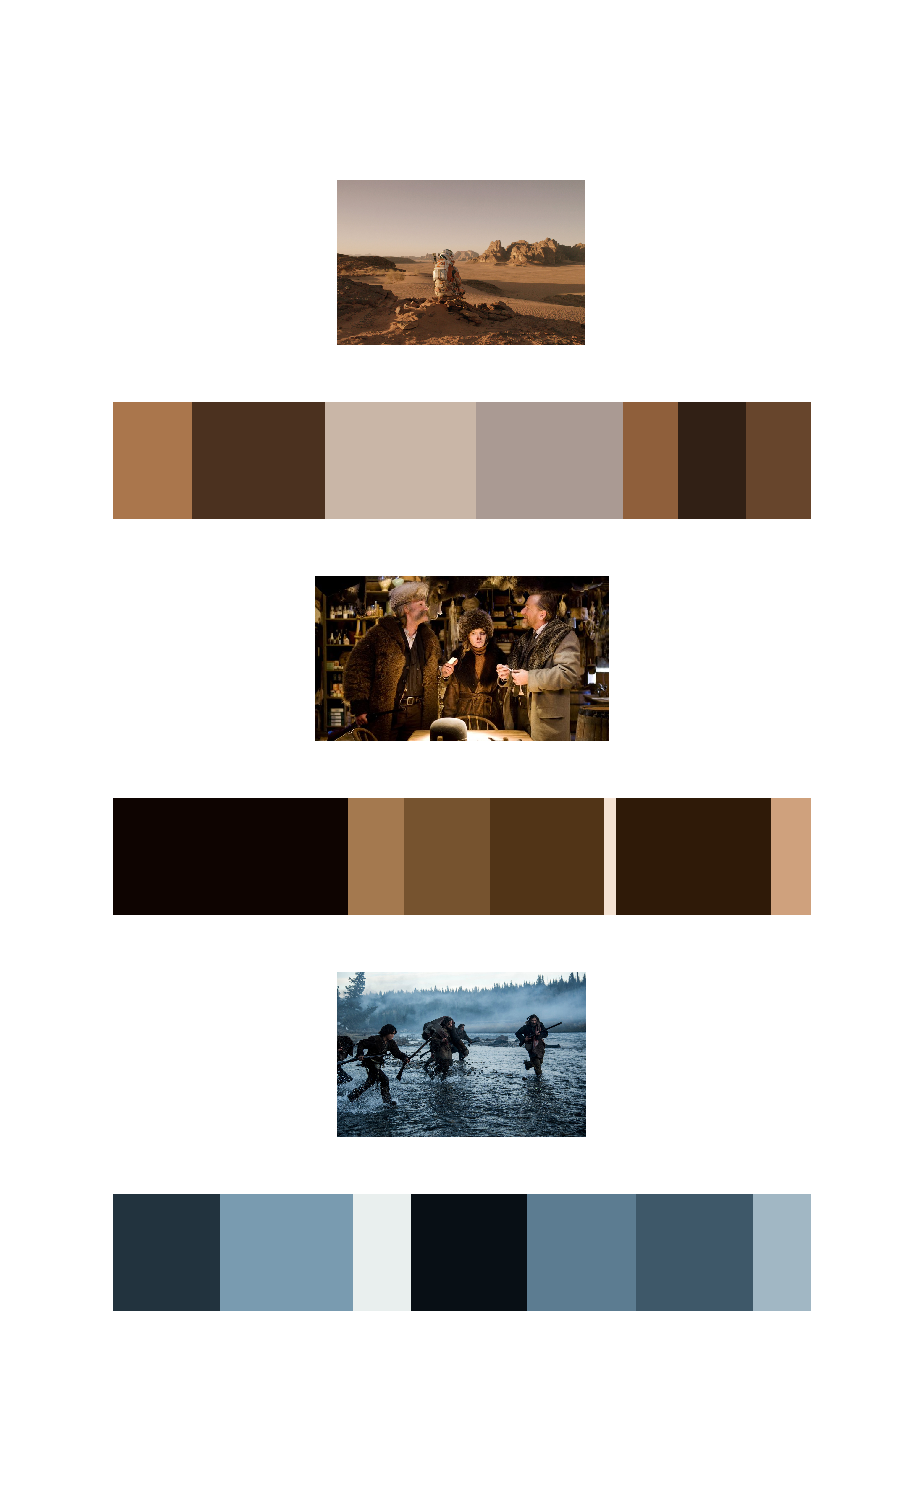

In [71]:
fig, ax = plt.subplots(6, 1, figsize=(9, 15))
ax = ax.ravel()
for i in range(3):
    ax[2*i].imshow(images[i])
    ax[2*i].axis('off')
    ax[2*i+1].imshow(palletes[i])
    ax[2*i+1].axis('off')

## [Affinity propagation](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AffinityPropagation.html) - метод распространения близости

В отличие от алгоритма *К-средних*, данный подход не требует заранее определять число кластеров, на которое мы хотим разбить наши данные. Основная идея алгоритма заключается в том, что нам хотелось бы, чтобы наши наблюдения кластеризовались в группы на основе того, как они "общаются", или насколько они похожи друг на друга.

Заведём для этого какую-нибудь метрику "похожести", определяющуюся тем, что 

$$\large s(x_i, x_j) > s(x_i, x_k)$$

если наблюдение $x_i$ больше похоже на наблюдение $x_j$, чем на $x_k$. Простым примером такой похожести будет отрицательный квадрат расстояния 

$$\large s(x_i, x_j) = - \| x_i - x_j \|^2 $$

.

Теперь опишем сам процесс "общения". Для этого заведём две матрицы, инициализируемые нулями, одна из которых $r_{i,k}$ будет описывать, насколько хорошо $k$-тое наблюдение подходит для того, чтобы быть "примером для подражания" для $i$-того наблюдения относительно всех остальных потенциальных "примеров", а вторая — $a_{i,k}$ будет описывать, насколько правильным было бы для $i$-того наблюдения выбрать $k$-тое в качестве такого "примера". 

После этого данные матрицы обновляются по очереди по правилам:

$$\large r_{i,k} \leftarrow s(x_i, x_k) - \max_{k'\neq k}\{a_{i,k'} + s(x_i, x'_k) \}$$
$$\large a_{i,k} \leftarrow \min \left( 0, r_{k,k} + \sum_{i' \notin \{i,k\}} \max(0, r_{i', k}) \right)$$

Более подробно как работает алгоритм [Affinity propagation](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AffinityPropagation.html), можно прочитать [здесь](https://habr.com/ru/post/321216/). Оттуда же рекомендации того, в каких случаях его применять:
* У вас не очень большой ($< 10^5-10^6$) или в меру большой, но разреженный ($< 10^6-10^7$) датасет
* Заранее известна функция близости
* Вы ожидаете увидеть множество кластеров различной формы и немного варьирующимся количеством элементов
* Вы готовы повозиться с постобработкой
* Сложность элементов датасета значения не имеет
* Свойства функции близости значения не имеют
* Количество кластеров значения не имеет


Визулизация того, как работает алгоритм:
<img src="images/ap.gif"/>


## [DBSCAN](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html) (Density-based spatial clustering of applications with noise) - плотностный алгоритм кластеризации пространственных данных с присутствием шума

Метод основан на оценке плотности точек между собой. Он позволяет выделят кластеры сложной формы за счет анализа плотности близлежащих соседей. По этой причине он оперирует 2 основными параметрами:
* *eps* - максимальное расстояние между 2 точками, при котором они могут считаться соседями
* *min_samples* - минимальное количество соседей, при котором создаётся отдельный кластер

Препарирование алгоритма DBSCAN показано [здесь](https://habr.com/ru/post/322034/). Оттуда же рекомендации:
* У вас в меру большой датасет с $N\approx10^6$. Даже $N\approx10^7-10^8$, если под рукой оптимизированная и распаралленная реализация.
* Заранее известна функция близости, симметричная, желательно, не очень сложная. KD-Tree оптимизация часто работает только с евклидовым расстоянием.
* Вы ожидаете увидеть сгустки данных экзотической формы: вложенные и аномальные кластеры, складки малой размерности.
* Плотность границ между сгустками меньше плотности наименее плотного кластера. Лучше если кластеры вовсе отделены друг от друга.
* Сложность элементов датасета значения не имеет. Однако их должно быть достаточно, чтобы не возникало сильных разрывов в плотности (см. предыдущий пункт).
* Количество элементов в кластере может варьироваться сколь угодно.
* Количество выбросов значения не имеет (в разумных пределах), если они рассеяны по большому объёму.
* Количество кластеров значения не имеет.



Визуализация работы алгоритма:
<img src="images/DBSCAN.gif"/>

и еще одна с позитивным настроем на светлое будущее

<img src="images/DBSCAN_smile.gif"/>

## Метрики кластеризации

* ARI - [Adjusted Rand Index](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.adjusted_rand_score.html)
* AMI - [Adjusted Mutual Information](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.adjusted_mutual_info_score.html#sklearn.metrics.adjusted_mutual_info_score)
* Гомогенность - [homogeneity score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.homogeneity_score.html#sklearn.metrics.homogeneity_score)
* Полнота - [completeness score ](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.completeness_score.html)
* [V-мера](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.v_measure_score.html#sklearn.metrics.v_measure_score)
* Силуэт - [silhouette](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html)

# Линейные модели: линейная и логистическая регрессия

Рассуждения и текст взяты [отсюда](https://habr.com/ru/company/ods/blog/323890/) и [отсюда](https://habr.com/ru/company/ods/blog/322076/).

Будем рассматривать поиск целевой функции $ y $ от параметров $ x $ в следующем виде:

$$\large y = \sum_{i=0}^{m}w_i x_i = \overrightarrow{w}^T \overrightarrow{x} $$

Зададим модель $ \overrightarrow{y} $:

$$\large \overrightarrow{y} = \mathbf{X}\,\overrightarrow{w} + \epsilon,$$

* $\overrightarrow{y} \in \mathbb{R}^n$ - объясняемая (или целевая) переменная
* $ w $ - вектор параметров модели (веса)
* $\mathbf{X}$ - матрица наблюдений и признаков размерности $n$ строк на $m+1$ столбцов (включая фиктивную единичную колонку слева) с полным рангом по столбцам: $rank (\mathbf{X})=m+1$
* $\epsilon$ - случайная переменная, соответствующая случайной, непрогнозируемой ошибке модели.

Перепишем наблюдения модели для каждого наблюдения:
$$ y_i = \sum_{j=0}^{m}w_j\,X_{ij} + \epsilon_j$$ 

Также на модель накладываются следующие ограничения (иначе это будет какая то другая регрессия, но точно не линейная):
* матожидание случайных ошибок равно нулю: $\forall i: \mathbb{E}[\epsilon_i] = 0$;
* дисперсия случайных ошибок одинакова и конечна, это свойство называется [гомоскедастичностью](https://en.wikipedia.org/wiki/Homoscedasticity): $\forall  i: \mathrm{Var}(\epsilon_i)=\sigma^2 < \infty$
* случайные ошибки не скоррелированы: $\forall i \neq j: \mathrm{Cov} (\epsilon_i, \epsilon_j) = 0$.

Оценка $\hat{w}_i$ весов $w_i$ называется линейной, если:
$$\large \hat{w}_i = w_{1i}y_1 + w_{2i}y_2 + \ldots + w_{ni}y_n,$$

где $\forall k\,w_{ki}$ зависит только от наблюдаемых данных $ X $ и почти наверняка нелинейно. Так как решением задачи поиска оптимальных весов будет именно линейная оценка, то и модель называется *линейной регрессией*. 

Оценка $\hat{w}_i$ называется несмещенной тогда, когда матожидание оценки равно реальному, но неизвестному значению оцениваемого параметра:

$$ \large \Bbb{E}[\hat{w}_i] = w_i $$.

Один из способов вычислить значения параметров модели является **метод наименьших квадратов (МНК)**, который минимизирует среднеквадратичную ошибку между реальным значением зависимой переменной и прогнозом, выданным моделью:

$$ \large \mathcal{L}(X, \overrightarrow{y}, \overrightarrow{w}) = \dfrac{1}{2n}\sum_{i=1}^{n} \left( y_i - \overrightarrow{w}^T \overrightarrow{x}_i \right)^2 = \\ 
\large = \dfrac{1}{2n}\|\overrightarrow{y} - X \overrightarrow{w} \|_{2}^{2} = \\ 
\large = \dfrac{1}{2n}(\overrightarrow{y} - X \overrightarrow{w})^T(\overrightarrow{y} - X \overrightarrow{w}) $$

Для решения данной оптимизационной задачи необходимо вычислить производные по параметрам модели, приравнять их к нулю и решить полученные уравнения относительно $\overrightarrow{w}$:

$$\large \dfrac{\partial \mathcal{L}}{\partial \overrightarrow{w}} = 0 \iff \overrightarrow{w} = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T \overrightarrow{y}$$.

Имея в виду все определения и условия описанные выше, мы можем утверждать, опираясь на теорему [Маркова-Гаусса](https://ru.wikipedia.org/wiki/%D0%A2%D0%B5%D0%BE%D1%80%D0%B5%D0%BC%D0%B0_%D0%93%D0%B0%D1%83%D1%81%D1%81%D0%B0_%E2%80%94_%D0%9C%D0%B0%D1%80%D0%BA%D0%BE%D0%B2%D0%B0), что оценка МНК является лучшей оценкой параметров модели, среди всех линейных и несмещенных оценок, то есть обладающей наименьшей дисперсией.

**Метод максимального правдоподобия.** 

Почему мы минимизируем среднеквадратичную ошибку, а не что-то другое? Ведь можно минимизировать среднее абсолютное значение невязки или еще что-то. Единственное, что произойдёт в случае изменения минимизируемого значения, так это то, что мы выйдем из условий теоремы Маркова-Гаусса, и наши оценки перестанут быть лучшими среди линейных и несмещенных.

Посмотрим на модель с вероятностной точки зрения. Будем считать, что случайные ошибки берутся из центрированного нормального распределения:

$$\large \epsilon_i \sim \mathcal{N}(0, \sigma^2) $$.

Тогда модель можно представить в следующем виде:

$$\large \mathcal{p}(y_i | \mathbf{X}, \overrightarrow{w}) = \sum_{j=1}^{m} w_j \mathbf{X}_{ij} + \mathcal{N}(0, \sigma^2) = \mathcal{N}(\sum_{j=1}^{m} w_j \mathbf{X}_{ij}, \sigma^2)$$.

Так как примеры берутся независимо (ошибки не скоррелированы – одно из условий теоремы Маркова-Гаусса), то полное правдоподобие данных будет выглядеть как произведение функций плотности $p(y_i)$. Рассмотрим логарифм правдоподобия, что позволит нам перейти от произведения к сумме:

$$\large \log{\mathcal{p}}(\overrightarrow{y} | \mathbf{X}, \overrightarrow{w}) = \log \prod_{i=1}^{n} \mathcal{N}(\sum_{j=1}^{m} w_j \mathbf{X}_{ij}, \sigma^2) =  \sum_{i=1}^{n} \log{\mathcal{N}} ( \sum_{j=1}^{m} w_j \mathbf{X}_{ij}, \sigma^2) = \\ \large -\dfrac{n}{2}\log{2\pi\sigma^2} - \dfrac{1}{2 \sigma^2}\sum_{i=1}^{n}\left(y_i - \overrightarrow{w}^T \overrightarrow{x}_i\right)^2$$ 

Мы хотим найти гипотезу максимального правдоподобия, т.е. нам нужно максимизировать выражение $ \log{\mathcal{p}}(\overrightarrow{y} | \mathbf{X}, \overrightarrow{w})$, а это то же самое, что и максимизация его логарифма. Обратите внимание, что при максимизации функции по какому-то параметру можно выкинуть все члены, не зависящие от этого параметра:

$$\large \hat{w} = arg\,max_{w} \log{p}(\overrightarrow{y} | \mathbf{X}, \overrightarrow{w}) = \\ 
\large = arg\,max_{w} -\dfrac{n}{2}\log{2\pi\sigma^2} - \dfrac{1}{2 \sigma^2}\sum_{i=1}^{n}\left(y_i - \overrightarrow{w}^T \overrightarrow{x}_i\right)^2 \\ 
\large = arg\,max_{w} - \dfrac{1}{2 \sigma^2}\sum_{i=1}^{n}\left(y_i - \overrightarrow{w}^T \overrightarrow{x}_i\right)^2 = \\ 
\large = arg\,max_{w} -\mathcal{L}(\mathbf{X},\overrightarrow{y}, \overrightarrow{w}) $$

Таким образом, мы увидели, что максимизация правдоподобия данных – это то же самое, что и минимизация среднеквадратичной ошибки (при справедливости указанных выше предположений). Получается, что именно такая функция стоимости является следствием того, что ошибка распределена нормально, а не как-то по-другому.

**Разложение ошибки на смещение и разброс (Bias-variance decomposition).** 

Поговорим немного о свойствах ошибки прогноза линейной регрессии (в принципе эти рассуждения верны для всех алгоритмов машинного обучения). В свете предыдущего пункта мы выяснили, что:
* истинное значение целевой переменной складывается из некоторой детерминированной функции $f(\overrightarrow{x})$ и случайной ошибки $\epsilon$: $y = f(\overrightarrow{x}) + \epsilon$
* ошибка распределена нормально с центром в нуле и некоторым разбросом: $ \epsilon \sim \mathcal{N}(0, \sigma^2)$
* истинное значение целевой переменной тоже распределено нормально: $ y \sim \mathcal{N}(f(\overrightarrow{x}), \sigma^2)$
* мы пытаемся приблизить детерминированную, но неизвестную функцию $f(\overrightarrow{x})$ линейной функцией от регрессоров $\hat{f}(\overrightarrow{x})$, которая, в свою очередь, является точечной оценкой функции $ f $ в пространстве функций (точнее, мы ограничили пространство функций параметрическим семейством линейных функций), т.е. случайной переменной, у которой есть среднее значение и дисперсия.

Тогда ошибка в точке \overrightarrow{x} раскладывается следующим образом:

$$\large Err(\overrightarrow{x}) = \mathbb{E}\left[ \left( y - \hat{f}(\overrightarrow{x}) \right)^2 \right] = \\
\large = \mathbb{E} \left[ y^2 \right] + \mathbb{E}\left[ \left( \hat{f}(\overrightarrow{x}\right)^2 \right] - 2\,\mathbb{E}\left[y\hat{f}(\overrightarrow{x})\right] = \\
\large = \mathbb{E} \left[ y^2 \right] + \mathbb{E} \left[ \hat{f}^2 \right] - 2\,\mathbb{E}\left[y\hat{f}\right]$$

Для наглядности опустим обозначение аргумента функций. Рассмотрим каждый член в отдельности, первые два расписываются легко по формуле $ Var(z) = \mathbb{E}[z^2] - \mathbb{E}[z]^2 $:

$$\large \mathbb{E}[y^2] = Var(y) + \mathbb{E}[y]^2 = \sigma^2 + f^2 $$

$$ \large \mathbb{E}[\hat{f}^2] = Var\left(\hat{f}\right) + \mathbb{E}\left[\hat{f}\right]^2 $$

И теперь последний член суммы. Мы помним, что ошибка и целевая переменная независимы друг от друга:

$$ \large \mathbb{E}[y\hat{f}] = \mathbb{E} \left[ (f+\epsilon) \hat{f} \right] 
\large = \mathbb{E} \left[ f \hat{f} \right] + \mathbb{E}[\epsilon\hat{f}]
\large = f \mathbb{E} \left[ \hat{f} \right] + \mathbb{E} [\epsilon] \mathbb{E} \left[ \hat{f} \right] = f\mathbb{E}\left[\hat{f}\right] $$

Наконец, собираем все вместе:

$$ \large Err(\overrightarrow{x}) = \mathbb{E}\left[ \left( y - \hat{f}(\overrightarrow{x}) \right)^2 \right] = \\
= \large \sigma^2 + f^2 + Var(\hat{f}) + \mathbb{E}\left[\hat{f}\right]^2 - 2f\mathbb{E}\left[\hat{f}\right] = \\
= \large (f - \mathbb{E}\left[\hat{f}\right])^2 + Var\left( \hat{f} \right)^2 + \sigma^2$$.

Таким образом, получим итоговое выражение:
$$\Huge Err(\overrightarrow{x}) = Bias\left(\hat{f}\right)^2 + Var\left(\hat{f}\right) + \sigma^2$$

Итак, мы достигли цели всех вычислений, описанных выше, последняя формула говорит нам, что ошибка прогноза любой модели вида $y = f(\overrightarrow{x}) + \epsilon $ складывается из:

* квадрата смещения $\large Bias\left(\hat{f}\right)$ – средняя ошибка по всевозможным наборам данных;
* дисперсии $\large Var\left(\hat{f}\right) $ - вариативность ошибки, то, на сколько ошибка будет отличаться, если обучать модель на разных наборах данных;
* неустранимой ошибки: $\large \sigma^2$.

Если с последней мы ничего сделать не можем, то на первые два слагаемых мы можем как-то влиять. В идеале, конечно же, хотелось бы свести на нет оба этих слагаемых (левый верхний квадрат рисунка), но на практике часто приходится балансировать между смещенными и нестабильными оценками (высокая дисперсия).

<img src="images/bias_var.png"/>

Как правило, при увеличении сложности модели (например, при увеличении количества свободных параметров) увеличивается дисперсия (разброс) оценки, но уменьшается смещение. Из-за того что тренировочный набор данных полностью запоминается вместо обобщения, небольшие изменения приводят к неожиданным результатам (переобучение). Если же модель слабая, то она не в состоянии выучить закономерность, в результате выучивается что-то другое, смещенное относительно правильного решения.

<img src="images/model_complexity.png"/>

Теорема Маркова-Гаусса как раз утверждает, что МНК-оценка параметров линейной модели является самой лучшей в классе несмещенных линейных оценок, то есть с наименьшей дисперсией. Это значит, что если существует какая-либо другая несмещенная модель тоже из класса линейных моделей, то мы можем быть уверены, что $ Var\left(\hat{f}\right) \leq Var\left(g\right) $.

Визуализация линейной регрессии:
<img src="images/linear_regression.gif"/>


# Логистическая регрессия

**Линейный классификатор.** Основная идея линейного классификатора заключается в том, что признаковое пространство может быть разделено гиперплоскостью на два полупространства, в каждом из которых прогнозируется одно из двух значений целевого класса. Если это можно сделать без ошибок, то обучающая выборка называется *линейно разделимой*.

<img src="images/linear.png"/>

Мы уже знакомы с линейной регрессией и методом наименьших квадратов. Рассмотрим задачу бинарной классификации, причем метки целевого класса обозначим "+1" (положительные примеры) и "-1" (отрицательные примеры).
Один из самых простых линейных классификаторов получается на основе регрессии вот таким образом:

$$\large a(\overrightarrow{x})  = sign (\overrightarrow{x}^T x),$$

* $ \overrightarrow{x} $ - вектор признаков примера (вместе с единицей);
* $ \overrightarrow{w} $ - веса в линейной модели (вместе со смещением $w_0$);
* $sign(\bullet) $ – функция "сигнум", возвращающая знак своего аргумента;
* $ a(\overrightarrow{x}) $ - ответ классификатора на примере $ \overrightarrow{x} $.

**Логистическая регрессия как линейный классификатор.** Логистическая регрессия является частным случаем линейного классификатора, но она обладает хорошим "умением" – прогнозировать вероятность $p_{+}$ отнесения примера $ \overrightarrow{x}_i$ к классу "+":

$$ \large p_{+} = P\left(y_i=1  \, | \, \overrightarrow{x}_i, \overrightarrow{w}\right) $$

Прогнозирование не просто ответа ("+1" или "-1"), а именно вероятности отнесения к классу "+1" во многих задачах является очень важным бизнес-требованием. Например, в задаче кредитного скоринга, где традиционно применяется логистическая регрессия, часто прогнозируют вероятность невозврата кредита ($p_{+}$). Клиентов, обратившихся за кредитом, сортируют по этой предсказанной вероятности (по убыванию), и получается скоркарта — по сути, рейтинг клиентов от плохих к хорошим. Ниже приведен игрушечный пример такой скоркарты. 

<img src="images/scoring.png"/>

Итак, мы хотим прогнозировать вероятность $p_+ \in [0,1]$, а пока умеем строить линейный прогноз с помощью МНК: $b(\overrightarrow{x}) = \overrightarrow{w}^T \overrightarrow{x} \in \mathbb{R}$. Каким образом преобразовать полученное значение в вероятность, пределы которой – $[0, 1]$? Очевидно, для этого нужна некоторая функция $f: \mathbb{R} \rightarrow [0,1]$. В модели логистической регрессии для этого берется конкретная функция:

$$ \LARGE \sigma(z) = \dfrac{1}{1 + \exp^{-z}} $$

<img src="images/sigmoid.png"/>

Обозначим $P(X)$ вероятностью происходящего события $X$. Тогда отношение вероятностей $OR(X)$ определяется из $\dfrac{P(X)}{1-P(X)}$, а это — отношение вероятностей того, произойдет ли событие или не произойдет. Очевидно, что вероятность и отношение шансов содержат одинаковую информацию. Но в то время как $P(X)$ находится в пределах от 0 до 1, $OR(X)$ находится в пределах от 0 до $\infty$.

Если вычислить логарифм $OR(X)$ (то есть называется логарифм шансов, или логарифм отношения вероятностей), то легко заметить, что $\log OR(X) \in \mathbb{R} $. Его-то мы и будем прогнозировать с помощью МНК.

Посмотрим, как логистическая регрессия будет делать прогноз $p_+ = P\left(y_i | \overrightarrow{x}_i, \overrightarrow{w}\right)$ пока считаем, что веса $\overrightarrow{w}$ мы как-то получили, т.е. обучили модель. 

* **Шаг1.** Вычислить значение $w_0 + w_1x_1 + w_2x_2 + \ldots = \overrightarrow{w}^T \overrightarrow{x}$ (уравнение $ \overrightarrow{w}^T\overrightarrow{x} = 0$ задает гиперплоскость, разделяющую примеры на 2 класса).

* **Шаг 2.** Вычислить логарифм отношения шансов: $\large \log{OR_+} = \overrightarrow{w}^T\overrightarrow{x} $.

* **Шаг 3.** Имея прогноз шансов на отнесение к классу "+" – $OR_+$, вычислить $p_+$ с помощью простой зависимости:

$$ \LARGE p_+ = \dfrac{OR_+}{1+OR_+} = \dfrac{\exp^{\overrightarrow{w}^T\overrightarrow{x}}}{1+\exp^{\overrightarrow{w}^T\overrightarrow{x}}} = \dfrac{1}{1 + \exp^{-\overrightarrow{w}^T\overrightarrow{x}}} = \sigma(\overrightarrow{w}^T\overrightarrow{x}) $$

В правой части мы получили как раз сигмоид-функцию.

Итак, логистическая регрессия прогнозирует вероятность отнесения примера к классу "+" (при условии, что мы знаем его признаки и веса модели) как сигмоид-преобразование линейной комбинации вектора весов модели и вектора признаков примера:

$$\LARGE p_+ (x_i) = P(y_i = 1 | \ \overrightarrow{x}_i, \overrightarrow{w}) = \sigma(\overrightarrow{w}^T\overrightarrow{x}_i) $$.

**Принцип максимального правдоподобия и логистическая регрессия.**

Отступ классификации на объекте $\overrightarrow{x}_i$: 

$$M(\overrightarrow{x}_i) = y_i \overrightarrow{w}^T\overrightarrow{x}_i $$.

Если он неотрицателен, модель не ошибается на объекте $\overrightarrow{x}_i$, если же отрицателен – значит, класс для $\overrightarrow{x}_i$ спрогнозирован неправильно. Заметим, что отступ определен для объектов именно обучающей выборки, для которых известны реальные метки целевого класса $y_i$.

Логистическая функция потерь:

$$ \Huge \mathcal{L}_{log}(X, \overrightarrow{y}, \overrightarrow{w}) = \sum_{i=1}{l} \log{1 + exp^{-y_i\overrightarrow{w}^T \overrightarrow{x}_i}}$$.

<img src="images/log_loss.png"/>